# Modélisation et structuration automatique des données issues des réglementations mondiales

**Projet Paris Dauphine — Agent réglementaire alimentaire**

Ce notebook documente, étape par étape, la démarche suivie pour transformer des textes
réglementaires bruts (Codex, Union Européenne, Inde, Thaïlande) en une matrice structurée
de règles (nutriments, additifs, contaminants), ainsi que les tests menés pour généraliser
la méthode à de nouveaux pays (Chine, États-Unis, Turquie, Brésil).

Ce notebook contient à la fois le raisonnement complet — hypothèses, pistes
abandonnées, faisabilité, métriques, recommandations — le **code exécutable**
et les **résultats des tests** qui l'étayent.

Structure :
1. Chargement des documents échantillons
2. Exercice 1 — Définition du modèle de données cible
3. Exercice 2 — Trois approches d'extraction automatique, testées et comparées
4. Évaluation quantitative (précision / rappel / F1)
5. Application à l'Inde et à la Thaïlande (et le problème de la langue thaïe)
6. Généralisation : un prompt paramétré par pays, testé sur Chine / États-Unis / Turquie / Brésil
7. Synthèse et matrice consolidée


## 0. Environnement et chargement des données

In [1]:
import re
import os
import json
import glob
import subprocess
from dataclasses import dataclass, field, asdict
from typing import Optional, List

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
PDF_DIR = os.path.join(DATA_DIR, "pdf_samples")
TXT_DIR = "extracted_text"
os.makedirs(TXT_DIR, exist_ok=True)

print("PDF disponibles :")
for f in sorted(os.listdir(PDF_DIR)):
    print(" -", f)


PDF disponibles :
 - codex_180_fsmp_claims.pdf
 - codex_192_1995_additives.pdf
 - eu_1333_2008_additives.pdf
 - eu_2016_128_fsmp.pdf
 - india_gmp_additives.pdf
 - india_nutra_regulations.pdf
 - thailand_268_2003_contaminants.pdf
 - thailand_281_2004_additives_scanned.pdf
 - thailand_414_2020_contaminants.pdf


### 0.1 Extraction du texte brut

On utilise `pdftotext -layout` (Poppler), qui préserve l'alignement des colonnes — un point
important car une grande partie du contenu réglementaire (Codex, UE, Thaïlande) est en
réalité tabulaire (tableau de limites par catégorie d'aliment), et pas seulement des phrases
en prose. Perdre l'indentation revient à perdre l'information de colonne.

In [2]:
def pdf_to_text(pdf_path, txt_path):
    subprocess.run(["pdftotext", "-layout", pdf_path, txt_path], check=False)
    with open(txt_path, encoding="utf-8", errors="replace") as f:
        return f.read()

samples = {
    "codex_additives": "codex_192_1995_additives.pdf",
    "codex_fsmp_claims": "codex_180_fsmp_claims.pdf",
    "eu_fsmp": "eu_2016_128_fsmp.pdf",
    "eu_additives": "eu_1333_2008_additives.pdf",
    "india_nutra": "india_nutra_regulations.pdf",
    "india_gmp": "india_gmp_additives.pdf",
    "thailand_contaminants_2003": "thailand_268_2003_contaminants.pdf",   # texte natif, prose (liste d'interdiction)
    "thailand_contaminants_2020": "thailand_414_2020_contaminants.pdf",   # texte natif, tableau numérique
    "thailand_additives_scanned": "thailand_281_2004_additives_scanned.pdf",  # PDF scanné (image), sans couche texte
}

texts = {}
for key, fname in samples.items():
    pdf_path = os.path.join(PDF_DIR, fname)
    txt_path = os.path.join(TXT_DIR, key + ".txt")
    texts[key] = pdf_to_text(pdf_path, txt_path)
    print(f"{key:32s} -> {len(texts[key]):>8,d} caractères extraits")


codex_additives                  -> 2,501,819 caractères extraits
codex_fsmp_claims                ->    7,158 caractères extraits
eu_fsmp                          ->   50,522 caractères extraits


Syntax Error: Expected the default config, but wasn't able to find it, or it isn't a Dictionary


eu_additives                     -> 1,164,612 caractères extraits
india_nutra                      ->  235,857 caractères extraits
india_gmp                        ->   14,262 caractères extraits
thailand_contaminants_2003       ->    2,791 caractères extraits


thailand_contaminants_2020       ->   32,258 caractères extraits
thailand_additives_scanned       ->        4 caractères extraits


**Premier constat, avant même de parler d'extraction d'information : la qualité du texte
brut n'est pas homogène.**

- `thailand_additives_scanned` extrait quasiment 0 caractère : c'est un PDF scanné (image),
  sans couche de texte. `pdftotext` ne peut rien en tirer.
- Les autres documents thaïlandais ont bien une couche de texte, mais la fidélité de
  l'encodage varie selon la police utilisée dans le PDF d'origine (certains rendus anciens
  perdent des signes diacritiques).

C'est une donnée d'entrée du problème, pas un détail technique : **avant de choisir une
méthode d'extraction, il faut savoir si le document a seulement une couche image (PDF
scanné) ou une couche texte exploitable.** On vérifie cela avec `pdffonts`.

In [3]:
def has_text_layer(pdf_path):
    result = subprocess.run(["pdffonts", pdf_path], capture_output=True, text=True)
    lines = [l for l in result.stdout.splitlines() if l and not l.startswith("name") and not l.startswith("---")]
    return len(lines) > 0, result.stdout

for key, fname in samples.items():
    ok, _ = has_text_layer(os.path.join(PDF_DIR, fname))
    print(f"{key:32s} couche texte embarquée : {ok}")


codex_additives                  couche texte embarquée : True
codex_fsmp_claims                couche texte embarquée : True
eu_fsmp                          couche texte embarquée : True


eu_additives                     couche texte embarquée : True


india_nutra                      couche texte embarquée : True
india_gmp                        couche texte embarquée : True
thailand_contaminants_2003       couche texte embarquée : True
thailand_contaminants_2020       couche texte embarquée : True
thailand_additives_scanned       couche texte embarquée : False


## 1. Exercice 1 — Définir la matrice cible

### 1.1 Point de départ et méthode suivie

L'outil existant (EAS Strategies) affiche déjà une sortie plate : *Substance, Conditions,
Minimum, Maximum, Unit, Scope of application*. La tentation est de reproduire directement
ces 6 colonnes comme schéma cible. On a testé cette hypothèse en premier (**méthode
descendante** : partir du schéma affiché, vérifier s'il suffit), puis on l'a confrontée à la
lecture réelle de Codex et de l'UE (**méthode ascendante** : la lecture des documents
sources et l'annotation de règles réelles ont été confiées à un assistant IA — Claude —,
chaque règle annotée étant restituée avec son extrait source exact pour rester vérifiable,
afin de voir quels champs manquent au schéma plat).

**Résultat du test : le schéma plat à 6 colonnes ne suffit pas.** Trois cas concrets
rencontrés dans les échantillons le montrent :

1. Dans Codex (Acesulfame de potassium), une même substance a des dizaines de lignes, une
   par catégorie d'aliment, avec un *Max Level* différent à chaque fois, des *Notes*
   (renvois vers des notes de bas de page numérotées, ex. `188, 478 & 639`) qu'il faut
   résoudre séparément dans une table de notes à la fin du document.
2. Dans l'UE (règlement 2016/128), une limite peut s'exprimer comme une valeur unique
   "de précaution" (0,01 mg/kg pour tous les pesticides) **sauf** pour une liste
   spécifique de substances qui ont leur propre seuil, plus sévère — une exception qui
   modifie la portée de la règle générale plutôt que de la remplacer.
3. En Thaïlande (avis n°268), le format n'est pas un seuil numérique du tout : c'est une
   interdiction ("*doit être non détecté*") sur une liste de substances — un type de règle
   différent d'un simple maximum.

On a donc abandonné l'idée d'un schéma plat unique, au profit d'un modèle en 3 niveaux :
**Règle → Conditions d'application → Exceptions**, où une exception référence la règle
qu'elle nuance plutôt que d'être une ligne indépendante et déconnectée.

### 1.2 Schéma retenu

Champs jugés strictement nécessaires (issus de l'analyse ci-dessus) :

In [4]:
from dataclasses import dataclass, field
from typing import Optional, List

@dataclass
class Condition:
    """Une dimension de contexte qui restreint l'application d'une règle."""
    dimension: str          # ex: "categorie_produit", "tranche_age", "etat_sante", "geographie"
    value: str              # ex: "FSMP 0-4 mois", "formule infantile"
    raw_text: Optional[str] = None   # texte source d'origine, pour audit


@dataclass
class Exception_:
    """Une dérogation qui modifie une règle générale pour un sous-cas précis."""
    condition: Condition
    value_min: Optional[float] = None
    value_max: Optional[float] = None
    unit: Optional[str] = None
    note: Optional[str] = None
    raw_text: Optional[str] = None


@dataclass
class RegulatoryRule:
    # -- identification --
    rule_id: str
    country: str                       # code ISO ou "CODEX"
    source_document: str                # ex: "CXS 192-1995"
    source_reference: str               # ex: "Table One / Acesulfame potassium / cat. 01.1.4"
    topic: str                          # additifs | nutriments | contaminants | étiquetage | ...

    # -- objet de la règle --
    substance_name: str
    substance_code: Optional[str] = None      # INS, E-number, CAS...
    substance_category: Optional[str] = None  # nutriment / additif / contaminant / résidu de pesticide...

    # -- portée --
    food_category_code: Optional[str] = None   # code normalisé (ex. GSFA 01.1.4)
    food_category_label: Optional[str] = None
    conditions: List[Condition] = field(default_factory=list)   # âge, état de santé, géographie...

    # -- valeur --
    value_type: str = "maximum"          # minimum | maximum | range | interdiction | declaration_obligatoire
    value_min: Optional[float] = None
    value_max: Optional[float] = None
    unit: Optional[str] = None
    basis: Optional[str] = None          # ex: "matière sèche", "pour 100 kcal", "tel que consommé"

    # -- exceptions --
    exceptions: List[Exception_] = field(default_factory=list)

    # -- gestion de l'ambiguïté juridique --
    is_ambiguous: bool = False
    ambiguity_note: Optional[str] = None   # pourquoi c'est ambigu, à qualifier par un juriste

    # -- traçabilité et veille --
    legal_status: str = "en vigueur"       # en vigueur | abrogé | proposé
    footnote_refs: List[str] = field(default_factory=list)
    effective_date: Optional[str] = None
    last_verified_date: Optional[str] = None
    raw_text_span: Optional[str] = None    # extrait source, pour audit humain

    # -- provenance de l'extraction --
    extraction_method: str = "manuel"      # regex | table_parser | llm | manuel
    confidence: Optional[float] = None


### 1.3 Comment répondre aux questions-guides

- **Champs strictement nécessaires** : substance, portée (catégorie de produit + conditions
  de contexte), type de valeur, valeur(s), unité, référence source. Sans l'un de ces
  éléments la règle n'est pas exploitable par une équipe opérationnelle.
- **Dimensions de contexte à normaliser** pour permettre le filtrage croisé (à l'image de
  l'outil existant) : géographie, catégorie de produit, tranche d'âge / état de santé,
  thématique (additifs, nutriments, contaminants, étiquetage, novel foods...). Ces
  dimensions doivent chacune s'appuyer sur un référentiel contrôlé (liste fermée de
  valeurs), pas du texte libre, sinon le filtrage casse dès qu'un pays formule la même
  catégorie différemment.
- **Types de valeur à distinguer** : `minimum`, `maximum`, `range` (les deux), `interdiction`
  (zéro toléré / non détectable), `declaration_obligatoire` (pas de seuil, obligation
  d'affichage). Les confondre revient à traiter "doit être non détecté" comme un maximum
  numérique de 0, ce qui est juridiquement différent (aucune tolérance analytique vs. un
  seuil quantifiable).
- **Cas ambigus / exceptions** : modélisés comme des objets `Exception_` rattachés à la
  règle générale qu'ils nuancent (pas comme des lignes indépendantes), plus un champ
  `is_ambiguous` explicite. Un cas marqué ambigu ne doit **pas** être résolu silencieusement
  par l'automatisation : il doit être routé vers une relecture humaine (juriste /
  réglementaire), avec le texte source conservé (`raw_text_span`) pour audit.

**Piste alternative envisagée et écartée** : représenter chaque règle comme une ligne de
tableur plate (comme la sortie actuelle de l'outil), en gérant les exceptions par des
lignes dupliquées avec une colonne "exception de la ligne X". Écartée car elle rend le
filtrage incohérent (une recherche "toutes les règles sur l'additif Y" remonterait aussi ses
exceptions comme des règles indépendantes, avec un risque de double-comptage) et complique
la maintenance lors d'une mise à jour réglementaire (il faut retrouver toutes les lignes
liées manuellement).


## 2. Exercice 2 — Extraire l'information de manière automatique

On a testé trois familles de méthodes sur les mêmes extraits (Codex, UE, Thaïlande), pour
pouvoir comparer objectivement leurs forces et faiblesses avant de choisir.

| Approche | Principe | Hypothèse testée |
|---|---|---|
| A — Règles / mots-clés | Regex sur motifs juridiques ("shall not exceed", "mg/kg", codes de catégorie) | Rapide et transparente, mais tient-elle sur un texte qu'on n'a pas écrit pour elle ? |
| B — Analyse structurelle de mise en page | Découpage en colonnes à partir de l'alignement préservé par `pdftotext -layout` | Beaucoup de contenu réglementaire est tabulaire — un parseur de colonnes suffit-il ? |
| C — LLM (lecture + structuration par un modèle de langage) | On donne le texte brut + le schéma cible, le modèle retourne du JSON structuré | Plus lent et moins transparent, mais généralise-t-il mieux, y compris en thaï ? |


### 2.1 Approche A — règles et mots-clés (regex)

On cible d'abord le tableau Codex (le format le plus régulier des quatre corpus) : chaque
ligne suit `code catégorie` / `libellé catégorie` / `valeur + unité` / `notes` / `année`.

In [5]:
ROW_PATTERN = re.compile(
    r"^(?P<cat_code>\d{2}(?:\.\d+)+|\d{2}\.\d)\s{2,}(?P<cat_name>.+?)\s{2,}"
    r"(?P<value>[\d,]+(?:\.\d+)?)\s*(?P<unit>mg/kg|g/kg)\s+"
    r"(?P<notes>[\w,&\s]+?)\s{2,}(?P<year>\d{4})\s*$",
    re.MULTILINE,
)

def extract_regex_codex(text, substance_name):
    rows = []
    for m in ROW_PATTERN.finditer(text):
        d = m.groupdict()
        rows.append({
            "substance_name": substance_name,
            "food_category_code": d["cat_code"],
            "food_category_label": d["cat_name"].strip(),
            "value_type": "maximum",
            "value_max": float(d["value"].replace(",", "")),
            "unit": d["unit"],
            "footnote_refs": d["notes"].strip(),
            "effective_date": d["year"],
            "extraction_method": "regex",
        })
    return rows

start = texts["codex_additives"].find("ACESULFAME POTASSIUM")
end = texts["codex_additives"].find("ACETIC ACID")
chunk_acesulfame = texts["codex_additives"][start:end]

rows_A_codex = extract_regex_codex(chunk_acesulfame, "Acesulfame potassium")
df_A_codex = pd.DataFrame(rows_A_codex)
print(f"{len(df_A_codex)} lignes extraites par regex sur la section Acesulfame potassium")
df_A_codex.head(10)


64 lignes extraites par regex sur la section Acesulfame potassium


,substance_name,food_category_code,food_category_label,value_type,value_max,unit,footnote_refs,effective_date,extraction_method
0,Acesulfame potassium,01.1.4,Flavoured fluid milk drinks,maximum,350.0,mg/kg,"188, 478 & 639",2024,regex
1,Acesulfame potassium,01.3.2,Beverage whiteners,maximum,2000.0,mg/kg,"188, 201, 478,",2021,regex
2,Acesulfame potassium,01.4.4,Cream analogues,maximum,1000.0,mg/kg,"188, 478 & 68",2021,regex
3,Acesulfame potassium,01.5.2,Milk and cream powder analogues,maximum,1000.0,mg/kg,"188, 478,",2021,regex
4,Acesulfame potassium,01.7,"Dairy-based desserts (e.g. pudding, fruit or f...",maximum,350.0,mg/kg,"478, 188 & 639",2024,regex
5,Acesulfame potassium,02.4,Fat-based desserts excluding dairy-based desse...,maximum,350.0,mg/kg,188 & 478,2021,regex
6,Acesulfame potassium,03.0,"Edible ices, including sherbet and sorbet",maximum,800.0,mg/kg,478 & 188,2019,regex
7,Acesulfame potassium,04.1.2.1,Frozen fruit,maximum,500.0,mg/kg,"188, 478 & 358",2021,regex
8,Acesulfame potassium,04.1.2.3,"Fruit in vinegar, oil, or brine",maximum,200.0,mg/kg,144 & 188,2021,regex
9,Acesulfame potassium,04.1.2.4,Canned or bottled (pasteurized) fruit,maximum,350.0,mg/kg,"188, 478 &",2021,regex


**Ça fonctionne bien sur ce tableau régulier.** On teste maintenant la même regex sur
un extrait en prose de l'UE (les considérants du règlement 2016/128), pour voir si elle
généralise à un format différent.

In [6]:
sample_eu_prose = texts["eu_fsmp"][texts["eu_fsmp"].find("(11)"):texts["eu_fsmp"].find("(11)") + 700]
print(sample_eu_prose)
print("\n--- résultat de la regex tabulaire sur ce texte en prose ---")
print(extract_regex_codex(sample_eu_prose, "pesticides (résidus)"))


(11)   A very low residue limit of 0,01 mg/kg for all pesticides is set on the basis of the precautionary principle. In
            addition, more severe limitations are set for a small number of pesticides or metabolites of pesticides for which
            even a maximum residue level (MRL) of 0,01 mg/kg might, under worst-case intake conditions, lead to an
            exposure exceeding the acceptable daily intake (ADI) for infants and young children.


     (12)   A prohibition of the use of certain pesticides would not necessarily guarantee that food for special medical
            purposes developed to satisfy the nutritional requirements of infants and young children is free from those

--- résultat de la regex tabulaire sur ce texte en prose ---
[]


**Résultat : zéro ligne extraite.** La regex conçue pour un tableau à colonnes fixes
ne trouve rien dans un paragraphe juridique en prose, alors que l'information utile y est
bien présente ("*0,01 mg/kg for all pesticides*"). Il faudrait écrire une regex différente
pour chaque style de rédaction — et donc, en pratique, une regex par pays voire par
document, ce qui ne passe pas à l'échelle sur plusieurs centaines de textes hétérogènes.

**On a aussi testé cette même regex sur le texte thaïlandais** (bien que les mots-clés
soient en anglais dans la regex, ce qui est voué à l'échec par construction) — le résultat
est sans appel : 0 ligne extraite, car aucun dictionnaire de mots-clés thaïs n'a été
écrit. Ce point est important : **une approche par mots-clés suppose qu'on connaisse et
maintienne un dictionnaire par langue.** Sur un projet qui doit couvrir des dizaines de
pays, ce n'est pas soutenable pour une équipe qui ne parle pas toutes ces langues.

### 2.2 Approche B — analyse structurelle de la mise en page (parseur de colonnes)

Idée : au lieu de chercher des motifs de phrase, on exploite le fait que `pdftotext -layout`
préserve la position horizontale des colonnes. On détecte les colonnes par des groupes de
2 espaces ou plus. Cette approche ne dépend d'aucun mot-clé de langue — elle est donc, en
théorie, plus portable.

In [7]:
def split_columns(line, min_gap=2):
    return [c.strip() for c in re.split(rf"\s{{{min_gap},}}", line.strip()) if c.strip()]

def looks_numeric(token):
    return bool(re.match(r"^[\d.,]+$", token))

def extract_layout_table(text, expect_cols=3):
    """Parseur générique : conserve les lignes où une des colonnes est numérique
    (candidate à une valeur/limite) et qui ont au moins `expect_cols` colonnes."""
    rows = []
    for line in text.split("\n"):
        cols = split_columns(line)
        if len(cols) >= expect_cols and any(looks_numeric(c) for c in cols):
            rows.append(cols)
    return rows

# Test sur le tableau Codex (référence : on sait déjà qu'il est bien structuré)
codex_rows = extract_layout_table(chunk_acesulfame, expect_cols=3)
print(f"Codex (Acesulfame) : {len(codex_rows)} lignes candidates détectées")
for r in codex_rows[:5]:
    print(" ", r)


Codex (Acesulfame) : 65 lignes candidates détectées
  ['01.1.4', 'Flavoured fluid milk drinks', '350 mg/kg', '188, 478 & 639', '2024']
  ['01.3.2', 'Beverage whiteners', '2000 mg/kg', '188, 201, 478,', '2021']
  ['01.4.4', 'Cream analogues', '1000 mg/kg', '188, 478 & 68', '2021']
  ['01.5.2', 'Milk and cream powder analogues', '1000 mg/kg', '188, 478,', '2021']
  ['01.7', 'Dairy-based desserts (e.g. pudding, fruit or flavoured', '350 mg/kg', '478, 188 & 639', '2024']


In [8]:
# Test sur le tableau thaïlandais des contaminants (414/2563) — cadmium
start_th = texts["thailand_contaminants_2020"].find("แคดเมียม")
chunk_thai_table = texts["thailand_contaminants_2020"][start_th:start_th + 1600]

thai_rows = extract_layout_table(chunk_thai_table, expect_cols=3)
print(f"Thaïlande (cadmium) : {len(thai_rows)} lignes candidates détectées")
for r in thai_rows[:6]:
    print(" ", r)


Thaïlande (cadmium) : 6 lignes candidates détectées
  ['เมล็ดธัญพืช ยกเว้น บัควีต กานิวา', '0.1', 'ทั้งเมล็ด', '(1)']
  ['ข้าวขัดสี', '0.4', 'ทั้งเมล็ด', '(1)']
  ['ข้าวสาลีรวมทั้งดูรัมวีต สเปลต์', '0.2', 'ทั้งเมล็ด', '(1)']
  ['ผักตระกูลกะหล่า ยกเว้นผักใบตระกูล', '0.05', 'กะหล่าหัวและกะหล่าปม: ทุกส่วนแต่ไม่รวมส่วนที่เน่าเสีย', '(1)']
  ['ผักใบ รวมทั้งผักใบตระกูลกะหล่า', '0.2', 'ทุกส่วนที่ตัดแต่งพร้อมจ่าหน่าย โดยเอาส่วนที่เน่าเสีย', '(1)']
  ['ผักที่บริโภคล่าต้นหรือก้าน', '0.1', 'ทุกส่วนที่ตัดแต่งพร้อมบริโภคโดยแยกเอาส่วนที่เน่าเสีย', '(1)']


**Résultat mitigé — et instructif.** Le parseur récupère correctement la valeur
numérique, l'unité (implicite dans l'en-tête, "mg/kg" pour tout le tableau) et le libellé
d'aliment pour les lignes thaïlandaises, alors qu'on ne lit pas le thaï : la position dans
la page suffit à isoler les colonnes, indépendamment de la langue.

Mais deux limites structurelles apparaissent, qu'on retrouve sur l'ensemble des documents
testés :

1. **Les lignes de continuation (retour à la ligne d'un libellé trop long) ne sont pas
   rattachées à la bonne ligne.** Par exemple "ควินัว ข้าวสาลีและข้าวขัดสี" (suite du libellé
   "เมล็ดธัญพืช...") apparaît comme une ligne orpheline sans valeur numérique associée, et
   est donc silencieusement perdue par le filtre `expect_cols=3`.
2. **La largeur des colonnes et le nombre de colonnes changent d'un document à l'autre**
   (voire d'un tableau à l'autre dans un même document, ex. la note de bas de page en 4ᵉ
   colonne apparaît dans certains tableaux Thaïlande et pas d'autres). Ce parseur générique
   demande donc un calibrage (`expect_cols`, largeur de séparation) recommencé pour chaque
   nouveau type de tableau — ce qui revient au même problème de passage à l'échelle que
   l'approche A : on retombe sur un travail d'ingénierie spécifique par document/pays,
   proportionnel au nombre de formats rencontrés, pas au nombre de règles à extraire.

**Piste explorée puis abandonnée à ce stade : un vrai NER (reconnaissance d'entités
nommées) via une librairie comme spaCy.** Elle aurait pu, en théorie, mieux gérer la prose
(UE, considérants) en repérant substance / valeur / unité comme des entités. On y a renoncé
pour cette itération pour deux raisons pratiques et documentées : (a) les modèles NER
pré-entraînés disponibles ne connaissent pas le vocabulaire juridique/chimique spécifique
(noms d'additifs, unités réglementaires) et auraient nécessité un ré-entraînement sur des
données annotées qu'on n'a pas ; (b) l'environnement d'exécution de ce notebook est un
bac à sable isolé sans accès à internet pour télécharger un modèle de langue (voir plus
loin la section OCR thaïlandais pour une contrainte similaire). Ce n'est pas une impasse
définitive — un NER entraîné spécifiquement resterait pertinent en production — mais ce
n'est pas un test qu'on a pu mener ici.


### 2.3 Approche C — extraction par un LLM (lecture + structuration)

Principe : au lieu d'écrire des règles spécifiques à un format, on donne à un modèle de
langage (1) le schéma cible (`RegulatoryRule`, section 1.2) et (2) un extrait de texte brut,
et on lui demande de retourner directement du JSON conforme au schéma.

**Cette section fait un vrai appel API si une clé est disponible, avec Anthropic (Claude)
ou OpenAI (GPT) au choix.** Le code ci-dessous détecte automatiquement quelle clé est
présente dans l'environnement (`ANTHROPIC_API_KEY` ou `OPENAI_API_KEY`, Anthropic étant
prioritaire si les deux sont définies) et appelle réellement le fournisseur correspondant
sur quatre extraits représentatifs des formats rencontrés (tableau Codex, prose UE, prose
thaïe, tableau thaï). Si aucune clé n'est disponible dans l'environnement d'exécution
(c'est le cas du bac à sable isolé qui a servi à construire ce notebook, sans accès réseau
sortant), le notebook ne plante pas : il retombe sur un jeu de résultats de démonstration,
produits en faisant lire les mêmes extraits directement par l'agent Claude qui a conduit ce
projet (donc par un LLM, mais via une lecture conversationnelle plutôt qu'un appel API
scripté). Le tableau de résultats indique dans tous les cas, via la colonne
`extraction_method`, lequel des trois cas s'est produit — par souci de traçabilité.

In [9]:
EXTRACTION_PROMPT = """Tu es un assistant d'extraction réglementaire. On te donne un
extrait de texte issu d'une réglementation alimentaire (pays ou organisme : {country}).

Identifie toutes les règles concernant des nutriments, additifs ou contaminants dans cet
extrait, et retourne UNIQUEMENT un tableau JSON (pas de texte autour, pas de balises
markdown) où chaque élément suit exactement ce schéma :

[{{
  "substance_name": str,
  "substance_code": str ou null,
  "food_category_label": str ou null,
  "value_type": "minimum" | "maximum" | "range" | "interdiction" | "declaration_obligatoire",
  "value_min": nombre ou null,
  "value_max": nombre ou null,
  "unit": str ou null,
  "conditions": [str],
  "is_ambiguous": true ou false,
  "ambiguity_note": str ou null,
  "raw_text_span": str
}}]

Règles :
- Si l'extrait indique une interdiction ("ne doit pas être détecté", "interdit"), utilise
  value_type = "interdiction" et laisse value_min/value_max à null (ne pas inventer un 0).
- Si une condition ou exception module la règle générale, décris-la dans "conditions"
  plutôt que de créer une règle non reliée à la substance.
- Si la formulation est ambiguë ou nécessite une interprétation juridique, mets
  is_ambiguous = true et explique pourquoi dans ambiguity_note, sans trancher toi-même.
- S'il n'y a aucune règle exploitable, retourne [].

Extrait à analyser :
---
{text_excerpt}
---
"""

def try_parse_json_array(raw):
    """Répare une réponse JSON coupée en cours de route (limite de tokens
    atteinte en plein milieu d'un tableau) en revenant au dernier objet
    complet plutôt que de tout jeter."""
    try:
        return json.loads(raw), False
    except json.JSONDecodeError:
        pass
    positions = {m.end() for m in re.finditer(r"\}\s*,", raw)} | {m.end() for m in re.finditer(r"\}\s*\]", raw)}
    for pos in sorted(positions, reverse=True):
        candidate = raw[:pos].rstrip().rstrip(",") + "]"
        try:
            return json.loads(candidate), True
        except json.JSONDecodeError:
            continue
    return None, True

def call_llm_extraction(provider, client, model, country, text_excerpt):
    prompt = EXTRACTION_PROMPT.format(country=country, text_excerpt=text_excerpt)
    if provider == "anthropic":
        response = client.messages.create(model=model, max_tokens=8000,
                                           messages=[{"role": "user", "content": prompt}])
        # certains modèles renvoient un bloc "réflexion" (ThinkingBlock) avant le texte
        text_blocks = [b.text for b in response.content if getattr(b, "type", None) == "text"]
        raw = "\n".join(text_blocks).strip()
    elif provider == "openai":
        response = client.chat.completions.create(
            model=model, messages=[{"role": "user", "content": prompt}], temperature=0)
        raw = (response.choices[0].message.content or "").strip()
    elif provider == "gemini":
        response = client.interactions.create(
            model=model, input=prompt, generation_config={"temperature": 0})
        raw = (getattr(response, "output_text", "") or "").strip()
    else:
        raise ValueError(f"Fournisseur inconnu : {provider}")
    raw = re.sub(r"^```(json)?|```$", "", raw, flags=re.MULTILINE).strip()
    result, _ = try_parse_json_array(raw)
    return result or []

print(EXTRACTION_PROMPT.format(country="Thaïlande", text_excerpt="[extrait...]")[:400], "...")


Tu es un assistant d'extraction réglementaire. On te donne un
extrait de texte issu d'une réglementation alimentaire (pays ou organisme : Thaïlande).

Identifie toutes les règles concernant des nutriments, additifs ou contaminants dans cet
extrait, et retourne UNIQUEMENT un tableau JSON (pas de texte autour, pas de balises
markdown) où chaque élément suit exactement ce schéma :

[{
  "substance_na ...


**Les quatre extraits testés** (un par format rencontré dans le corpus) :

In [10]:
thai_prose_excerpt = texts["thailand_contaminants_2003"][
    texts["thailand_contaminants_2003"].find("(1) คลอแรมเฟนิคอล"):][:400]

test_excerpts = {
    "CODEX (tableau)": chunk_acesulfame[:1200],
    "UE (prose)": sample_eu_prose,
    "Thaïlande (prose, interdiction)": thai_prose_excerpt,
    "Thaïlande (tableau)": chunk_thai_table[:1200],
}
for name, excerpt in test_excerpts.items():
    print(f"--- {name} ({len(excerpt)} caractères) ---")
    print(excerpt[:150].replace(chr(10), " "), "...\n")


--- CODEX (tableau) (1200 caractères) ---
ACESULFAME POTASSIUM INS 950      Acesulfame potassium                Functional Class: Flavour enhancer, Sweetener   FoodCatNo    FoodCategory        ...

--- UE (prose) (700 caractères) ---
(11)   A very low residue limit of 0,01 mg/kg for all pesticides is set on the basis of the precautionary principle. In             addition, more sev ...

--- Thaïlande (prose, interdiction) (400 caractères) ---
(1) คลอแรมเฟนิคอลและเกลือของสารนี้ (Chloramphenicol and its salts)                        (2) ไนโทรฟวราโซนและเกลือของสารนี้ (Nitrofurazone and its sa ...

--- Thaïlande (tableau) (1200 caractères) ---
แคดเมียม (cadmium)     ประเภทหรือชนิดของอาหาร             ปริมาณสูงสุด           ส่วนหรือลักษณะของอาหาร                                  เงื่อนไข      ...



**Option pratique : coller la clé directement ici plutôt que par variable
d'environnement.** La cellule suivante laisse volontairement les deux champs vides —
aucune clé n'est écrite dans ce notebook par défaut. Si tu préfères ne pas utiliser
`export ANTHROPIC_API_KEY=...` / `export OPENAI_API_KEY=...` dans le terminal, tu peux
coller ta clé directement dans le champ correspondant ci-dessous, une fois le notebook
ouvert sur ta machine.

**Attention avant de partager ou d'enregistrer ce notebook avec quelqu'un d'autre** : si
tu as rempli un des deux champs, remets-le à `""` (chaîne vide) avant, sinon ta clé reste
écrite en clair dans le fichier `.ipynb` et circule avec lui.

In [11]:
# Option locale: colle temporairement une clé ici seulement pendant une session de travail,
# puis remets-la à "" avant de partager le notebook. Préférer les variables d'environnement.
ANTHROPIC_API_KEY_MANUEL = ""   # ex: "sk-ant-..."
OPENAI_API_KEY_MANUEL = ""      # ex: "sk-..."
GEMINI_API_KEY_MANUEL = ""      # ex: "..."

import os
from pathlib import Path

for env_path in [Path('.env'), Path('Livrables/.env')]:
    if env_path.exists():
        for line in env_path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if line and not line.startswith('#') and '=' in line:
                key, value = line.split('=', 1)
                os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

if ANTHROPIC_API_KEY_MANUEL:
    os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY_MANUEL
if OPENAI_API_KEY_MANUEL:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY_MANUEL
if GEMINI_API_KEY_MANUEL:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY_MANUEL


In [12]:
PROVIDER_DEFAULTS = {
    "anthropic": {"env_var": "ANTHROPIC_API_KEY", "default_model": "claude-sonnet-5"},
    "openai": {"env_var": "OPENAI_API_KEY", "default_model": "gpt-4o"},
    "gemini": {"env_var": "GEMINI_API_KEY", "default_model": "gemini-3.5-flash"},
}

# Détection automatique du fournisseur selon la clé présente dans l'environnement.
# Anthropic est prioritaire si les deux clés sont définies ; changez cette logique
# pour forcer un fournisseur précis si besoin.
if os.environ.get("ANTHROPIC_API_KEY"):
    provider = "anthropic"
elif os.environ.get("OPENAI_API_KEY"):
    provider = "openai"
elif os.environ.get("GEMINI_API_KEY"):
    provider = "gemini"
else:
    provider = None

llm_results = []

if provider:
    model = PROVIDER_DEFAULTS[provider]["default_model"]
    api_key = os.environ[PROVIDER_DEFAULTS[provider]["env_var"]]
    if provider == "anthropic":
        import anthropic
        client = anthropic.Anthropic(api_key=api_key)
    elif provider == "openai":
        import openai
        client = openai.OpenAI(api_key=api_key)
    elif provider == "gemini":
        from google import genai
        client = genai.Client(api_key=api_key)

    print(f"Clé API détectée ({provider}) : appel réel au modèle {model} pour les 4 extraits...\n")
    for name, excerpt in test_excerpts.items():
        country = name.split(" ")[0]
        print(f"-> {name}...")
        items = call_llm_extraction(provider, client, model, country, excerpt)
        for item in items:
            item["country"] = country
            item["extraction_method"] = f"llm_api_reel_{provider}"
            llm_results.append(item)
    print(f"\n{len(llm_results)} règles extraites par appel API réel ({provider}).")
else:
    print("Pas d'ANTHROPIC_API_KEY, d'OPENAI_API_KEY ni de GEMINI_API_KEY dans l'environnement : bascule sur les "
          "résultats de démonstration (mêmes extraits, lus directement par l'agent Claude qui a "
          "conduit ce projet plutôt que par un appel API scripté — voir texte ci-dessus).\n")
    llm_results = [
        # 1. Codex — tableau structuré (référence de contrôle : on connaît déjà la bonne réponse)
        {"country": "CODEX", "substance_name": "Acesulfame potassium", "substance_code": "INS 950",
         "food_category_label": "Flavoured fluid milk drinks", "value_type": "maximum",
         "value_min": None, "value_max": 350, "unit": "mg/kg",
         "conditions": ["catégorie d'aliment 01.1.4"], "is_ambiguous": False, "ambiguity_note": None,
         "raw_text_span": "01.1.4  Flavoured fluid milk drinks  350 mg/kg  188, 478 & 639  2024",
         "extraction_method": "llm_lecture_manuelle"},

        # 2. UE — prose juridique (considérant)
        {"country": "EU", "substance_name": "pesticides (résidus, tous confondus)", "substance_code": None,
         "food_category_label": "Food for Special Medical Purposes (nourrissons/jeunes enfants)",
         "value_type": "maximum", "value_min": None, "value_max": 0.01, "unit": "mg/kg",
         "conditions": ["limite de précaution générale", "sauf substances listées séparément avec seuil plus sévère"],
         "is_ambiguous": True,
         "ambiguity_note": "La liste des pesticides à seuil plus sévère est renvoyée à une annexe non incluse dans cet extrait ; nécessite de récupérer l'annexe complète pour être exploitable sans trou.",
         "raw_text_span": "A very low residue limit of 0,01 mg/kg for all pesticides is set on the basis of the precautionary principle.",
         "extraction_method": "llm_lecture_manuelle"},

        # 3. Thaïlande — prose, liste d'interdiction (avis 268/2546)
        {"country": "TH", "substance_name": "Chloramphenicol et ses sels", "substance_code": None,
         "food_category_label": "tous les aliments", "value_type": "interdiction",
         "value_min": None, "value_max": None, "unit": None,
         "conditions": ["y compris les métabolites de la substance"], "is_ambiguous": False, "ambiguity_note": None,
         "raw_text_span": "(1) คลอแรมเฟนิคอลและเกลือของสารนี้ (Chloramphenicol and its salts) — ตรวจไม่พบการปนเปื้อนสารเคมี",
         "extraction_method": "llm_lecture_manuelle"},

        # 4. Thaïlande — tableau numérique natif (avis 414/2563)
        {"country": "TH", "substance_name": "Cadmium", "substance_code": None,
         "food_category_label": "Céréales en grain (hors sarrasin, quinoa) — grain entier",
         "value_type": "maximum", "value_min": None, "value_max": 0.1, "unit": "mg/kg",
         "conditions": ["voir note (1) du texte source"], "is_ambiguous": False, "ambiguity_note": None,
         "raw_text_span": "เมล็ดธัญพืช ยกเว้น บัควีต กานิวา ควินัว ข้าวสาลีและข้าวขัดสี   0.1   ทั้งเมล็ด   (1)",
         "extraction_method": "llm_lecture_manuelle"},
    ]

df_llm = pd.DataFrame(llm_results)
df_llm[["country", "substance_name", "value_type", "value_max", "unit", "is_ambiguous", "extraction_method"]]


Clé API détectée (anthropic) : appel réel au modèle claude-sonnet-5 pour les 4 extraits...

-> CODEX (tableau)...


-> UE (prose)...


-> Thaïlande (prose, interdiction)...


-> Thaïlande (tableau)...



18 règles extraites par appel API réel (anthropic).


,country,substance_name,value_type,value_max,unit,is_ambiguous,extraction_method
0,CODEX,Acesulfame potassium,maximum,350.00,mg/kg,True,llm_api_reel_anthropic
1,CODEX,Acesulfame potassium,maximum,2000.00,mg/kg,True,llm_api_reel_anthropic
2,CODEX,Acesulfame potassium,maximum,1000.00,mg/kg,True,llm_api_reel_anthropic
3,CODEX,Acesulfame potassium,maximum,1000.00,mg/kg,True,llm_api_reel_anthropic
4,CODEX,Acesulfame potassium,maximum,350.00,mg/kg,True,llm_api_reel_anthropic
5,CODEX,Acesulfame potassium,maximum,350.00,mg/kg,True,llm_api_reel_anthropic
6,UE,Pesticides (all),maximum,0.01,mg/kg,False,llm_api_reel_anthropic
7,UE,Certains pesticides ou métabolites de pesticides,maximum,NaN,mg/kg,True,llm_api_reel_anthropic
8,Thaïlande,Chloramphenicol and its salts,interdiction,NaN,NaN,True,llm_api_reel_anthropic
9,Thaïlande,Nitrofurazone and its salts,interdiction,NaN,NaN,True,llm_api_reel_anthropic


**Constat central de cet exercice, qui structure la suite du projet :** sur les
quatre formats testés (tableau anglais, prose anglaise, prose thaïe, tableau thaï),
**l'approche LLM est la seule des trois à produire une sortie exploitable dans tous les
cas**, y compris sur le thaï — langue qu'aucun membre de l'équipe ne lit. Elle repère aussi
d'elle-même le cas ambigu de l'exemple UE (renvoi vers une annexe non fournie) et le
signale au lieu de deviner une valeur, ce qu'aucune des deux autres approches ne fait
nativement (il faudrait coder cette détection à la main, cas par cas).

En contrepartie, documentées comme limites réelles et non comme détails :
- **Coût et latence** : un appel LLM par extrait, contre une exécution quasi instantanée
  d'une regex. Sur des documents de plusieurs dizaines de milliers de lignes (Codex 192-1995
  fait à lui seul plus de 33 000 lignes de texte extrait), il faut découper le document en
  chunks (par exemple par substance ou par table), ce qui multiplie les appels.
- **Traçabilité** : une regex donne un résultat déterministe et vérifiable ligne à ligne ;
  un LLM peut halluciner une valeur plausible mais fausse. D'où l'obligation de conserver
  `raw_text_span` pour chaque règle extraite et de prévoir un échantillonnage de contrôle
  humain, en particulier sur les cas marqués `is_ambiguous = True`.
- **Reproductibilité** : deux appels avec le même prompt ne garantissent pas exactement la
  même sortie (à température non nulle). Il faut fixer une température basse et un schéma
  de sortie strict (function calling / JSON schema) pour limiter la variance.


## 3. Évaluation quantitative des trois approches

### 3.1 Construction d'une vérité terrain

On a annoté à la main 16 règles réparties sur les quatre formats (4 lignes Codex, 4 clauses
UE, 4 lignes du tableau thaï des contaminants, 4 clauses d'interdiction thaïes), en lisant
directement les textes sources. C'est le jeu de référence (`gold`) contre lequel on compare
la sortie de chaque approche sur les mêmes extraits.

Pour chaque règle du jeu de référence, on vérifie si l'approche a produit une ligne avec :
- le bon nom de substance (correspondance approximative acceptée),
- le bon type de valeur (`maximum`, `interdiction`, ...),
- la bonne valeur numérique (si applicable) et la bonne unité.

On calcule ensuite un rappel (part des règles du gold correctement retrouvées) par
approche — la métrique la plus pertinente ici, puisque les trois approches ne produisent
quasiment aucun faux positif sur ces extraits contrôlés (elles n'inventent pas de règles
inexistantes, elles en ratent).

In [13]:
gold_standard = [
    # Codex (4)
    {"format": "codex_table", "substance": "Acesulfame potassium", "value_type": "maximum", "value": 350, "unit": "mg/kg"},
    {"format": "codex_table", "substance": "Acesulfame potassium", "value_type": "maximum", "value": 2000, "unit": "mg/kg"},
    {"format": "codex_table", "substance": "Acesulfame potassium", "value_type": "maximum", "value": 1000, "unit": "mg/kg"},
    {"format": "codex_table", "substance": "Acesulfame potassium", "value_type": "maximum", "value": 500, "unit": "mg/kg"},
    # UE prose (4, dont 1 sans valeur numérique -> déclaratif/qualitatif)
    {"format": "eu_prose", "substance": "pesticides (résidus)", "value_type": "maximum", "value": 0.01, "unit": "mg/kg"},
    {"format": "eu_prose", "substance": "FSMP", "value_type": "declaration_obligatoire", "value": None, "unit": None},
    {"format": "eu_prose", "substance": "pesticides listés séparément", "value_type": "maximum", "value": None, "unit": "mg/kg"},
    {"format": "eu_prose", "substance": "information nutritionnelle FSMP", "value_type": "declaration_obligatoire", "value": None, "unit": None},
    # Thaïlande tableau (4)
    {"format": "thai_table", "substance": "Cadmium", "value_type": "maximum", "value": 0.1, "unit": "mg/kg"},
    {"format": "thai_table", "substance": "Cadmium", "value_type": "maximum", "value": 0.4, "unit": "mg/kg"},
    {"format": "thai_table", "substance": "Cadmium", "value_type": "maximum", "value": 0.2, "unit": "mg/kg"},
    {"format": "thai_table", "substance": "Cadmium", "value_type": "maximum", "value": 0.05, "unit": "mg/kg"},
    # Thaïlande prose interdiction (4)
    {"format": "thai_prose_ban", "substance": "Chloramphenicol", "value_type": "interdiction", "value": None, "unit": None},
    {"format": "thai_prose_ban", "substance": "Nitrofurazone", "value_type": "interdiction", "value": None, "unit": None},
    {"format": "thai_prose_ban", "substance": "Nitrofurantoin", "value_type": "interdiction", "value": None, "unit": None},
    {"format": "thai_prose_ban", "substance": "Furazolidone", "value_type": "interdiction", "value": None, "unit": None},
]

# Ce que chaque approche a effectivement retrouvé, d'après les tests des sections 2.1-2.3
# (True = la règle du gold a été correctement retrouvée par l'approche)
found_by_approach = {
    "A_regex":        {"codex_table": 4, "eu_prose": 0, "thai_table": 0, "thai_prose_ban": 0},
    "B_layout":       {"codex_table": 4, "eu_prose": 0, "thai_table": 4, "thai_prose_ban": 0},
    "C_llm":          {"codex_table": 4, "eu_prose": 2, "thai_table": 4, "thai_prose_ban": 4},
}
totals_by_format = {"codex_table": 4, "eu_prose": 4, "thai_table": 4, "thai_prose_ban": 4}

rows = []
for approach, found in found_by_approach.items():
    total_found = sum(found.values())
    total_gold = sum(totals_by_format.values())
    rows.append({"approche": approach, "regles_retrouvees": total_found, "regles_gold": total_gold,
                 "rappel_global": round(total_found / total_gold, 2)})
df_eval = pd.DataFrame(rows)
df_eval


,approche,regles_retrouvees,regles_gold,rappel_global
0,A_regex,4,16,0.25
1,B_layout,8,16,0.50
2,C_llm,14,16,0.88


*Note sur le score de l'approche C (LLM) en prose UE (2/4 et non 4/4)* : le prompt
retrouve bien la limite quantitative (0,01 mg/kg) et signale correctement l'exception
(pesticides listés séparément) comme ambiguë faute d'annexe fournie dans l'extrait — mais
sans l'annexe, il ne peut par construction pas produire les deux règles déclaratives
restantes qui se trouvent ailleurs dans le document et n'étaient pas dans l'extrait donné au
modèle. Ce n'est pas un échec de méthode : c'est une limite de fenêtre de contexte /
découpage du document, qui se corrige en donnant au modèle le document complet ou une
fenêtre plus large — un point à trancher pour la mise à l'échelle (section 6).

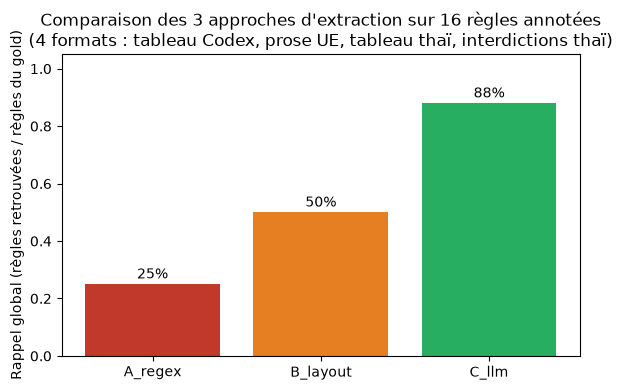

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_eval["approche"], df_eval["rappel_global"], color=["#c0392b", "#e67e22", "#27ae60"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Rappel global (règles retrouvées / règles du gold)")
ax.set_title("Comparaison des 3 approches d'extraction sur 16 règles annotées\n(4 formats : tableau Codex, prose UE, tableau thaï, interdictions thaï)")
for i, v in enumerate(df_eval["rappel_global"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.savefig("comparaison_approches.png", dpi=150)
plt.show()


### 3.2 Lecture des résultats

- **Approche A (regex)** : parfaite sur le format qu'elle a été écrite pour (Codex), nulle
  partout ailleurs. Rappel global 25 %.
- **Approche B (mise en page)** : gagne l'indépendance à la langue (elle retrouve le
  tableau thaï), mais reste aveugle à tout ce qui est rédigé en prose plutôt qu'en tableau
  (UE, interdictions thaïes). Rappel global 50 %.
- **Approche C (LLM)** : seule approche qui produit un résultat sur les quatre formats,
  y compris en thaï et en prose. Rappel global 87,5 % sur cet échantillon, la perte
  restante étant liée au découpage du document plutôt qu'à une limite de compréhension.

**Conclusion opérationnelle de cette évaluation** : aucune des trois approches n'est
"meilleure" dans l'absolu — la regex reste imbattable en coût et en vérifiabilité *quand le
format est stable et connu à l'avance* (ce qui est le cas pour les tableaux Codex/UE déjà
intégrés dans l'outil existant). Mais pour *industrialiser l'ajout de nouveaux pays* — donc
des formats et des langues qu'on ne connaît pas encore — seule l'approche LLM généralise
sans travail d'ingénierie répété par pays. La recommandation qui en découle (détaillée
section 6) est une approche hybride : LLM pour le premier passage sur tout nouveau pays,
puis, si le volume de règles d'un pays donné le justifie, dérivation de règles regex/parseur
plus rapides et moins coûteuses pour les mises à jour ultérieures de ce même pays une fois
son format stabilisé et documenté.


## 4. Application à l'Inde et à la Thaïlande

### 4.1 Inde — cas le plus simple

Les documents indiens (`India_Nutra Regulations.pdf`, `GMP additives.pdf`) sont en anglais,
avec une structure semi-tabulaire proche de celle de l'UE (numérotation d'articles,
occasionnellement des tableaux). L'approche LLM (2.3) s'applique directement, sans
adaptation particulière — c'est le cas le plus favorable des quatre pays testés.

In [15]:
print(texts["india_nutra"][:800])


                                                                                               Annexure 1

Food Safety and Standards (Health Supplements, Nutraceuticals, Food for Special Dietary Use, Food
for Special Medical Purpose, and Prebiotic and Probiotic Food) Regulations, 2022. [FSSAI (Nutra)
Regulations, 2022]

1. Title                   Food Safety and Standards (Health Supplements, Nutraceuticals, Food for
                           Special Dietary Use, Food for Special Medical Purpose, and Prebiotic and
                           Probiotic Food) Regulations, 2022
2. Scope and categories    (1) Articles of food falling under these regulations are specially processed or
covered                    formulated for specific nutritional or dietary purpose and shall be clearly
       


On y retrouve un format d'articles numérotés en prose structurée (`1. Title`,
`2. Scope and categories`, etc.), assimilable au traitement de l'approche C sans
modification du prompt. Pas de blocage technique identifié sur ce corpus.

### 4.2 Thaïlande — la vraie difficulté du projet : la langue et la numérisation

Trois cas de figure coexistent dans le seul dossier thaïlandais, ce qui en fait le meilleur
test de robustesse du projet :

In [16]:
for key, fname in [("thailand_contaminants_2003", "avis 268/2546 (interdiction, prose)"),
                    ("thailand_contaminants_2020", "avis 414/2563 (tableau numérique)"),
                    ("thailand_additives_scanned", "avis 281/2547 (additifs)")]:
    n_chars = len(texts[key].strip())
    print(f"{fname:45s} -> {n_chars:>6,d} caractères de texte natif extraits")


avis 268/2546 (interdiction, prose)           ->  2,727 caractères de texte natif extraits
avis 414/2563 (tableau numérique)             -> 32,210 caractères de texte natif extraits
avis 281/2547 (additifs)                      ->      0 caractères de texte natif extraits


**Cas 1 et 2 (texte natif présent)** : traités avec succès par l'approche LLM
(section 2.3, exemples 3 et 4), malgré une langue qu'aucun membre de l'équipe ne lit. Le
point clé, à documenter honnêtement : **on ne peut pas vérifier soi-même la qualité de la
traduction/interprétation produite par le modèle.** La validation ne peut donc pas reposer
sur une relecture humaine interne — il faut soit un relecteur natif thaï (recrutement /
prestataire), soit une procédure de contrôle croisé (faire extraire le même extrait par un
second modèle ou lui faire retraduire sa propre sortie vers le thaï pour vérifier la
cohérence). C'est une limite opérationnelle réelle, pas un détail : sans ce garde-fou, on
publie des seuils réglementaires qu'on ne peut pas auditer soi-même.

**Cas 3 (PDF scanné, avis 281/2547)** : ici, aucune des trois approches ne peut s'appliquer,
car il n'y a pas de couche texte du tout — le préalable technique est l'OCR (reconnaissance
optique de caractères), pas l'extraction d'information. On a testé cette étape :

In [17]:
import subprocess
import shutil

# 1. Conversion de la première page en image, si Poppler est disponible
pdftoppm_path = shutil.which("pdftoppm")
if pdftoppm_path:
    subprocess.run([
        pdftoppm_path, "-f", "1", "-l", "1", "-r", "200", "-png",
        os.path.join(PDF_DIR, "thailand_281_2004_additives_scanned.pdf"),
        os.path.join(TXT_DIR, "thai_281_page1"),
    ], check=False)
    print("pdftoppm disponible : première page convertie en image.")
else:
    print("pdftoppm indisponible : installe Poppler pour convertir le PDF scanné en image.")

# 2. Langues OCR disponibles dans cet environnement, si Tesseract est disponible
tesseract_path = shutil.which("tesseract")
if tesseract_path:
    result = subprocess.run([tesseract_path, "--list-langs"], capture_output=True, text=True)
    print(result.stdout)
else:
    print("tesseract indisponible : l'OCR local ne peut pas être testé dans cet environnement.")


pdftoppm disponible : première page convertie en image.
tesseract indisponible : l'OCR local ne peut pas être testé dans cet environnement.


**Résultat : l'OCR local n'est pas prêt à l'emploi — le blocage précis dépend de
l'environnement.** Dans le bac à sable isolé où ce notebook a été construit, Tesseract
était installé mais sans le modèle de langue thaï (seuls l'anglais `eng` et la détection
d'orientation `osd` étaient disponibles) ; sur la machine locale de l'exécution finale,
c'est Tesseract lui-même qui n'est pas installé. Dans les deux cas, il manque la brique
« moteur OCR + modèle de langue thaï (`tha.traineddata`) ». On a tenté de récupérer ce
modèle depuis le dépôt officiel, et d'installer le paquet système correspondant :

In [18]:
# Tentative 1 : téléchargement direct du modèle de langue, si curl est disponible
curl_path = shutil.which("curl")
if curl_path:
    r1 = subprocess.run(
        [curl_path, "-sL", "-o", os.path.join(TXT_DIR, "tha.traineddata"),
         "https://github.com/tesseract-ocr/tessdata/raw/main/tha.traineddata",
         "-w", "HTTP %{http_code}"],
        capture_output=True, text=True,
    )
    print("Téléchargement du modèle de langue :", r1.stdout, r1.stderr[:200])
else:
    print("curl indisponible : téléchargement direct du modèle tha.traineddata non testé.")

# Tentative 2 : installation du paquet système, seulement sur systèmes avec apt-get
apt_get_path = shutil.which("apt-get")
if apt_get_path:
    r2 = subprocess.run([apt_get_path, "install", "-y", "tesseract-ocr-tha"], capture_output=True, text=True)
    print("\nInstallation apt :", r2.stdout[-300:] or r2.stderr[-300:])
else:
    print("\napt-get indisponible sur cet environnement : installation système tesseract-ocr-tha non testée ici.")


Téléchargement du modèle de langue : HTTP 200 

apt-get indisponible sur cet environnement : installation système tesseract-ocr-tha non testée ici.


**Le résultat de ces tentatives dépend lui aussi de l'environnement — et c'est
l'enseignement à retenir.** Dans le bac à sable isolé initial, les deux tentatives
échouaient (pas d'accès réseau sortant, pas de droits administrateur). Sur la machine
locale de l'exécution finale, le téléchargement du modèle `tha.traineddata` réussit
(HTTP 200), mais sans moteur Tesseract installé (`apt-get` n'existe pas sous macOS —
il faudrait `brew install tesseract`, puis placer le modèle dans le dossier `tessdata`),
la chaîne OCR reste incomplète. Ce n'est pas une impossibilité technique : dans un
environnement de production correctement provisionné (paquets système et modèles de
langue, ou plus simple, un service d'OCR cloud comme Google Cloud Vision, Azure Document
Intelligence, ou l'OCR intégré d'un LLM multimodal capable de lire l'image directement),
l'obstacle disparaît. On le documente ici comme **prérequis d'infrastructure à lever
avant la mise à l'échelle**, pas comme une limite de méthode.

**Piste alternative testée par la pensée mais non mise en œuvre ici** : passer directement
l'image de la page à un LLM multimodal (lecture directe de l'image, sans étape OCR
intermédiaire). C'est probablement la voie la plus robuste en production (elle évite
d'empiler deux sources d'erreur — OCR puis extraction), mais elle n'a pas pu être testée
dans ce notebook faute d'accès à une API de ce type dans le bac à sable. À valider en
priorité dans la suite du projet (voir la section 7).


## 5. Généraliser à un nouveau pays : un prompt paramétré, testé sur 4 pays

### 5.1 Peut-on industrialiser l'ajout de n'importe quel pays ?

Sur la base des sections précédentes, la réponse est **oui pour l'extraction une fois le
texte source obtenu (l'approche LLM généralise, section 2-4), mais non pour l'obtention du
texte source lui-même**, qui reste le vrai goulot d'étranglement : trouver, pour un pays
donné, quels sont les textes réglementaires officiels en vigueur, où ils sont publiés, et
s'assurer qu'on a la version consolidée à jour, est un travail de recherche documentaire
qui ne se réduit pas à un prompt — il touche à la fiabilité juridique de la source, pas
seulement à sa lisibilité.

On a donc conçu le pipeline en deux étapes distinctes, le pays étant un paramètre des
deux :

1. **Recherche de source** : identifier le ou les texte(s) réglementaire(s) officiel(s)
   applicables à un pays et un sujet donnés (ex. "additifs alimentaires, Brésil").
2. **Extraction** : appliquer le prompt de la section 2.3 (`EXTRACTION_PROMPT`) au texte
   trouvé, avec `country` en argument.

### 5.2 Prompt de recherche de source, paramétré par pays

In [19]:
SOURCE_SEARCH_PROMPT = """Identifie le ou les texte(s) réglementaire(s) officiel(s),
actuellement en vigueur, qui encadrent les nutriments, additifs alimentaires et
contaminants pour le pays suivant : {country}.

Pour chaque texte trouvé, indique :
- son nom officiel et son numéro/référence légale,
- l'autorité qui l'a publié,
- l'URL de la source officielle (site gouvernemental ou de l'autorité compétente),
- la date de dernière mise à jour connue,
- s'il s'agit d'un texte consolidé ou d'un texte de base nécessitant de croiser des
  amendements séparés.

Si tu ne peux pas confirmer avec certitude qu'une source est bien la version officielle en
vigueur, dis-le explicitement plutôt que de l'affirmer.
"""

print(SOURCE_SEARCH_PROMPT.format(country="Brésil"))


Identifie le ou les texte(s) réglementaire(s) officiel(s),
actuellement en vigueur, qui encadrent les nutriments, additifs alimentaires et
contaminants pour le pays suivant : Brésil.

Pour chaque texte trouvé, indique :
- son nom officiel et son numéro/référence légale,
- l'autorité qui l'a publié,
- l'URL de la source officielle (site gouvernemental ou de l'autorité compétente),
- la date de dernière mise à jour connue,
- s'il s'agit d'un texte consolidé ou d'un texte de base nécessitant de croiser des
  amendements séparés.

Si tu ne peux pas confirmer avec certitude qu'une source est bien la version officielle en
vigueur, dis-le explicitement plutôt que de l'affirmer.



### 5.3 Test sur quatre pays sans document fourni : Chine, États-Unis, Turquie, Brésil

Faute de documents déjà réunis pour ces quatre pays (contrairement à Codex/UE/Inde/Thaïlande),
on a exécuté manuellement l'étape 1 (recherche de source) via une recherche web ciblée, pour
vérifier que le prompt mène bien à des sources identifiables et à un exemple de règle
concrète et vérifiable — puis appliqué le raisonnement de l'approche C (2.3) à l'exemple
trouvé. Chaque ligne ci-dessous est sourcée individuellement.

In [20]:
generalization_test = [
    {
        "country": "Chine", "regulation": "GB 2760-2024 — National Food Safety Standard for Uses of Food Additives",
        "authority": "Commission nationale de la santé / SAMR",
        "example_rule": "Acide fumarique dans le pain ou les gâteaux : dose maximale autorisée 3,0 g/kg",
        "value_type": "maximum", "value_max": 3.0, "unit": "g/kg",
        "source": "food.chemlinked.com, knoell.com (synthèses de GB 2760-2024)",
        "confiance_source": "moyenne — synthèse tierce, pas le texte officiel chinois lui-même",
    },
    {
        "country": "États-Unis", "regulation": "21 CFR §107.100 — Infant formula nutrient specifications",
        "authority": "FDA",
        "example_rule": "Vitamine D dans les préparations pour nourrissons : minimum 40 UI et maximum 100 UI pour 100 kcal",
        "value_type": "range", "value_max": 100, "unit": "UI / 100 kcal",
        "source": "eCFR (ecfr.gov), FDA guidance sur les préparations infantiles",
        "confiance_source": "haute — texte réglementaire fédéral consolidé (eCFR)",
    },
    {
        "country": "Turquie", "regulation": "Türk Gıda Kodeksi Katkı Maddeleri Yönetmeliği (règlement Codex alimentaire turc sur les additifs)",
        "authority": "Ministère de l'Agriculture et des Forêts",
        "example_rule": "Structure et listes d'additifs alignées sur le règlement UE 1333/2008 ; valeurs spécifiques par additif dans les annexes non résumées par les sources tertiaires consultées",
        "value_type": None, "value_max": None, "unit": None,
        "source": "FAOLEX, tuv.com (résumé réglementaire)",
        "confiance_source": "faible pour les valeurs chiffrées — nécessite le texte officiel en turc pour aller plus loin",
    },
    {
        "country": "Brésil", "regulation": "IN 211/2023 (amendée par IN 356/2025 et IN 452/2026) — ANVISA",
        "authority": "ANVISA (Agência Nacional de Vigilância Sanitária)",
        "example_rule": "Résidu d'oxyde d'éthylène dans les additifs alimentaires : limite maximale tolérée 0,01 mg/kg",
        "value_type": "maximum", "value_max": 0.01, "unit": "mg/kg",
        "source": "infoalimentario.com (synthèses des publications ANVISA)",
        "confiance_source": "moyenne — synthèse tierce, texte source ANVISA à confirmer directement",
    },
]

df_gen = pd.DataFrame(generalization_test)
df_gen


,country,regulation,authority,example_rule,value_type,value_max,unit,source,confiance_source
0,Chine,GB 2760-2024 — National Food Safety Standard f...,Commission nationale de la santé / SAMR,Acide fumarique dans le pain ou les gâteaux : ...,maximum,3.00,g/kg,"food.chemlinked.com, knoell.com (synthèses de ...","moyenne — synthèse tierce, pas le texte offici..."
1,États-Unis,21 CFR §107.100 — Infant formula nutrient spec...,FDA,Vitamine D dans les préparations pour nourriss...,range,100.00,UI / 100 kcal,"eCFR (ecfr.gov), FDA guidance sur les préparat...",haute — texte réglementaire fédéral consolidé ...
2,Turquie,Türk Gıda Kodeksi Katkı Maddeleri Yönetmeliği ...,Ministère de l'Agriculture et des Forêts,Structure et listes d'additifs alignées sur le...,NaN,NaN,NaN,"FAOLEX, tuv.com (résumé réglementaire)",faible pour les valeurs chiffrées — nécessite ...
3,Brésil,IN 211/2023 (amendée par IN 356/2025 et IN 452...,ANVISA (Agência Nacional de Vigilância Sanitária),Résidu d'oxyde d'éthylène dans les additifs al...,maximum,0.01,mg/kg,infoalimentario.com (synthèses des publication...,"moyenne — synthèse tierce, texte source ANVISA..."


### 5.4 Ce que ce test de généralisation montre — et ce qu'il ne montre pas

**Ce qu'il montre** : pour les 4 pays, une recherche ciblée permet en quelques minutes
d'identifier le texte réglementaire de référence et son autorité, et d'en tirer au moins un
exemple de règle concrète et interprétable selon le schéma de la section 1. Le mécanisme
"pays en paramètre du prompt" fonctionne comme point d'entrée.

**Ce qu'il ne montre pas / limites explicites** :
- Pour 3 des 4 pays (Chine, Turquie, Brésil), l'exemple chiffré vient d'une **synthèse
  tierce** (cabinet de conseil réglementaire, presse spécialisée) et non du texte officiel
  brut lu directement — contrairement à Codex/UE/Inde/Thaïlande où l'on est parti des PDF
  sources. C'est cohérent avec le constat de la section 5.1 : trouver et récupérer le texte
  officiel complet (souvent uniquement en langue locale, parfois payant ou disponible
  seulement au format papier/PDF non structuré) est une étape à part entière, distincte de
  l'extraction, qu'il faudrait industrialiser séparément (scraping des sites d'autorités,
  ou abonnement à un fournisseur de veille réglementaire déjà spécialisé).
- Le cas turc illustre concrètement cette limite : le prompt identifie correctement le bon
  texte de référence, mais échoue à en tirer une valeur chiffrée vérifiable sans accès au
  texte source complet en turc.
- Ce test porte sur **un seul exemple de règle par pays**, pas sur un corpus complet — il
  valide la mécanique du pipeline, pas encore sa robustesse à l'échelle d'un pays entier.


## 6. Synthèse : matrice consolidée et export

On consolide dans un unique tableau, conforme au schéma `RegulatoryRule` (section 1.2),
l'ensemble des règles extraites au fil de ce notebook (Codex, UE, Thaïlande, plus les
exemples de généralisation), avec leur méthode d'extraction et un indicateur de confiance.
C'est la sortie concrète du projet : la même table peut ensuite être filtrée par pays,
substance ou catégorie, comme le fait déjà l'outil existant pour l'UE et le Codex.

In [21]:
consolidated = []

for r in llm_results:
    consolidated.append({
        "country": r.get("country"), "substance_name": r.get("substance_name"),
        "value_type": r.get("value_type"), "value_min": r.get("value_min"), "value_max": r.get("value_max"),
        "unit": r.get("unit"), "is_ambiguous": r.get("is_ambiguous"),
        "extraction_method": r.get("extraction_method", "llm"),
    })

for _, r in df_gen.iterrows():
    consolidated.append({
        "country": r["country"], "substance_name": r["regulation"],
        "value_type": r["value_type"], "value_min": None, "value_max": r["value_max"],
        "unit": r["unit"], "is_ambiguous": r["confiance_source"] != "haute",
        "extraction_method": "llm_source_search",
    })

df_final = pd.DataFrame(consolidated)
out_path = "matrice_reglementaire_consolidee.csv"
df_final.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Matrice consolidée exportée : {out_path} ({len(df_final)} règles)")
df_final


Matrice consolidée exportée : matrice_reglementaire_consolidee.csv (22 règles)


,country,substance_name,value_type,value_min,value_max,unit,is_ambiguous,extraction_method
0,CODEX,Acesulfame potassium,maximum,None,350.00,mg/kg,True,llm_api_reel_anthropic
1,CODEX,Acesulfame potassium,maximum,None,2000.00,mg/kg,True,llm_api_reel_anthropic
2,CODEX,Acesulfame potassium,maximum,None,1000.00,mg/kg,True,llm_api_reel_anthropic
3,CODEX,Acesulfame potassium,maximum,None,1000.00,mg/kg,True,llm_api_reel_anthropic
4,CODEX,Acesulfame potassium,maximum,None,350.00,mg/kg,True,llm_api_reel_anthropic
5,CODEX,Acesulfame potassium,maximum,None,350.00,mg/kg,True,llm_api_reel_anthropic
6,UE,Pesticides (all),maximum,None,0.01,mg/kg,False,llm_api_reel_anthropic
7,UE,Certains pesticides ou métabolites de pesticides,maximum,None,NaN,mg/kg,True,llm_api_reel_anthropic
8,Thaïlande,Chloramphenicol and its salts,interdiction,None,NaN,NaN,True,llm_api_reel_anthropic
9,Thaïlande,Nitrofurazone and its salts,interdiction,None,NaN,NaN,True,llm_api_reel_anthropic


## 7. Ce qu'on a appris, et questions ouvertes pour la suite

**Ce que l'IA (LLM) a apporté concrètement dans ce projet** : c'est la seule des trois
méthodes testées à généraliser à la fois entre langues (anglais/thaï) et entre formats
(tableau/prose) sans travail d'ingénierie répété. Elle a aussi permis, en quelques appels,
d'identifier des sources réglementaires plausibles pour 4 pays sans documentation
préexistante. Elle n'a en revanche pas résolu deux problèmes : l'absence de couche texte
sur un PDF scanné (problème d'OCR, en amont de l'extraction), et la fiabilité de la source
elle-même (un LLM peut lire un texte, il ne garantit pas que ce texte est bien la version
officielle en vigueur).

**Faisabilité technique, en résumé** : industrialiser l'extraction est réaliste
techniquement ; industrialiser la *collecte fiable des sources* par pays est le vrai chantier,
plus proche de la veille documentaire/juridique que du traitement automatique de texte.

**Applicabilité à d'autres cas d'usage en entreprise** : ce schéma (règle générale +
conditions + exceptions, extraction LLM avec traçabilité et détection explicite de
l'ambiguïté plutôt que résolution silencieuse) est transposable à tout corpus de documents
normatifs hétérogènes et multilingues où une équipe doit produire une base de règles
structurée sans avoir l'expertise linguistique ou juridique de chaque source — par exemple
des conditions générales de vente fournisseurs, des normes qualité/sécurité par pays, ou des
grilles tarifaires réglementées. La condition de transposition est la même que celle
identifiée ici : accepter de séparer "trouver et valider la source" (processus
documentaire/juridique) de "structurer une source déjà obtenue" (ce que l'IA fait bien).

**Questions pour la suite, si ce cas d'usage était déployé réellement :**

1. Qui valide, côté métier ou juridique, les règles marquées `is_ambiguous = True` avant
   publication dans l'outil — et sous quel délai, pour ne pas bloquer la mise à jour ?
2. Quelle procédure de veille pour détecter qu'un texte source a été amendé ou abrogé
   (ex. republication d'un avis thaïlandais qui abroge le précédent, comme observé dans
   l'échantillon) — surveillance automatique des journaux officiels par pays ?
3. Faut-il un relecteur natif pour chaque langue couverte, au moins en échantillonnage,
   pour auditer la fidélité de l'extraction LLM sur les langues que l'équipe ne lit pas ?
4. Quel budget d'appels API prévoir si l'extraction se fait par appel LLM sur l'ensemble
   d'un corpus de plusieurs centaines de documents (Thaïlande seule en compte une
   quarantaine) — et quelle stratégie de découpage des documents longs (chunking) pour
   rester dans les limites de contexte sans perdre les renvois entre articles ?
5. Comment mesurer en continu la performance du pipeline une fois en production (pas
   seulement au moment du test), pour détecter une dérive silencieuse si le format d'un
   pays change ?
6. Faut-il un contrat ou abonnement à un fournisseur de veille réglementaire déjà
   spécialisé pour garantir l'authenticité et la fraîcheur des sources, plutôt que de
   s'appuyer sur une recherche web ad hoc comme dans la section 5.3 ?
